**Wine Quality Dataset**

Each wine is identified with an integer ID and described by data which are either related to chemical composition or to physicochemical properties
Additionally, to each wine an integer is assigned describing its 'quality' according to a sensory classification.

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# dataframes
dfr = pd.read_csv("winequality-red.csv", delimiter=";")
dfw = pd.read_csv("winequality-white.csv", delimiter=";")

# hue of graph
dfr['hue'] = 0
dfw['hue'] = 1

# put both types of wine into one dataset
df_wine = pd.concat([dfr, dfw], ignore_index = True)

# print full dataframe
print(df_wine)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4              0.70         0.00             1.9      0.076   
1               7.8              0.88         0.00             2.6      0.098   
2               7.8              0.76         0.04             2.3      0.092   
3              11.2              0.28         0.56             1.9      0.075   
4               7.4              0.70         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
6492            6.2              0.21         0.29             1.6      0.039   
6493            6.6              0.32         0.36             8.0      0.047   
6494            6.5              0.24         0.19             1.2      0.041   
6495            5.5              0.29         0.30             1.1      0.022   
6496            6.0              0.21         0.38             0.8      0.020   

      free sulfur dioxide  

4.01

The lines below can be used to view characteristics of the dataset.

In [8]:
dfr.info()

dfr['pH'].max()

dfr.max(axis=0)

dfr['pH'].min()

dfr.min(axis=0)

dfr.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
 12  hue                   1599 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 162.5 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,hue
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.0
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023,0.0
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569,0.0
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.0
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000,0.0
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000,0.0
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000,0.0
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,0.0


We can create a histogram of the red wines with seaborn

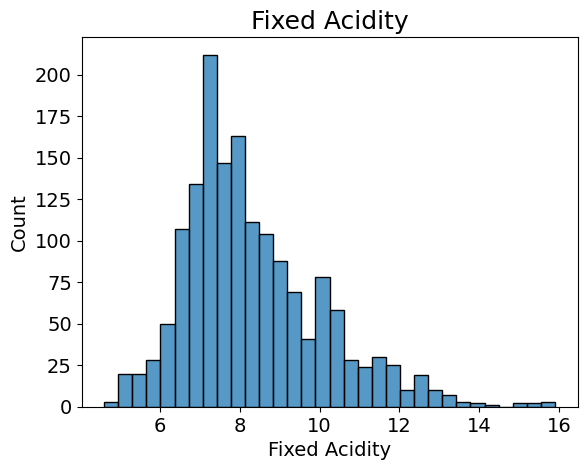

In [13]:
# red wines

hist_r = sns.histplot(x="fixed acidity", data = dfr,)
hist_r.axes.set_title("Fixed Acidity",fontsize=18)
hist_r.set_xlabel("Fixed Acidity",fontsize=14)
hist_r.set_ylabel("Count",fontsize=14)
hist_r.tick_params(labelsize=14)

Create boxplots on logarithmic scale. Unfortunately, the data isn't standardized.

(np.float64(0.0), np.float64(300.0), np.float64(12.5), np.float64(-0.5))

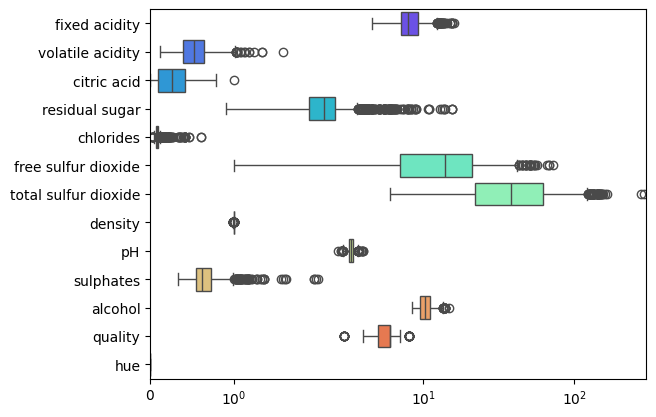

In [17]:
ax = sns.boxplot(data = dfr, orient = "h", palette = "rainbow")
ax.set_xscale('symlog')
ax.axis(xmin = 0, xmax = 300)

Standardize the dataset with scikit-learn.

stdev = 1

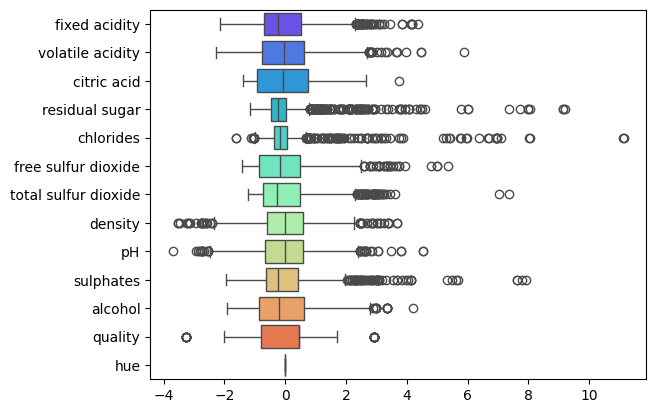

In [19]:
from sklearn.preprocessing import StandardScaler
scaled = StandardScaler().fit_transform(dfr)
dfr_scaled = pd.DataFrame(data=scaled, columns=dfr.columns)
ax = sns.boxplot(data=dfr_scaled, orient="h", palette="rainbow")

Check the correlation between the variables in the dataset.

<Axes: >

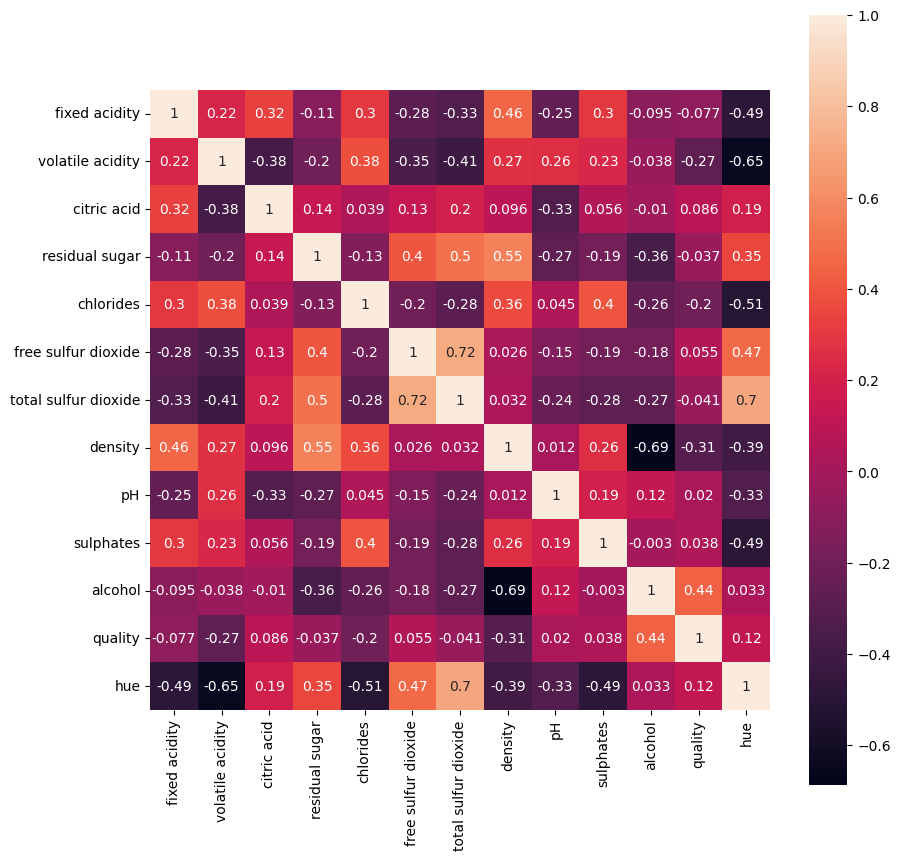

In [98]:
correlation = df_wine.corr(method='pearson')

fig = plt.gcf()

fig.set_size_inches(10,10)

sns.heatmap(correlation, annot = True,square = True)

Numerically check the correlation between acidity and pH.

In [66]:
from scipy.stats import pearsonr
def get_corr(col1, col2, temp_df):
    pearson_corr, p_value = pearsonr(temp_df[col1], temp_df[col2])
    print("Correlation between {} and {} is {:.2f}".format(col1, col2, pearson_corr))
    print("P-value of this correlation is {}".format(p_value))
get_corr('fixed acidity', 'pH', dfr)

Correlation between fixed acidity and pH is -0.68
P-value of this correlation is 4.06303403984401e-220


Use a heatmap to visualize the correlation using pandas.

<Axes: >

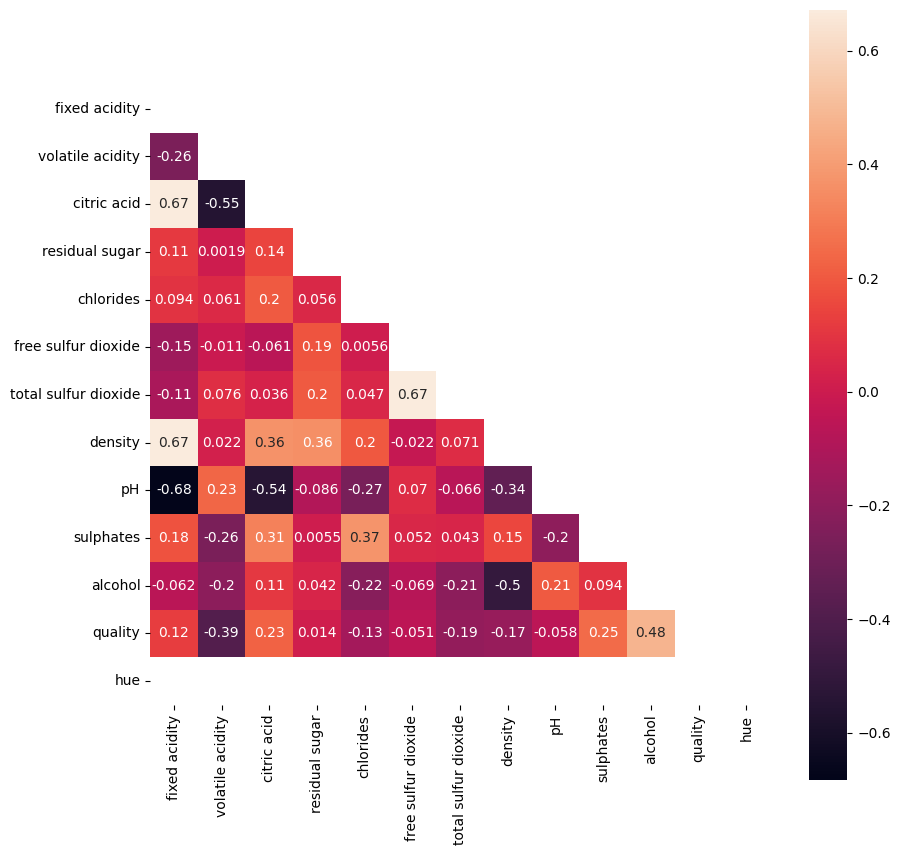

In [67]:
correlation = dfr.corr(method = 'pearson')

mask_triu = np.triu(correlation)

fig = plt.gcf()
fig.set_size_inches(10,10)

sns.heatmap(correlation, mask = mask_triu, annot = True, square = True)


Logistic regression for the red wines: extract the amount of alcohol for wine qualities 3 and 8.

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)

<Axes: xlabel='alcohol', ylabel='quality'>

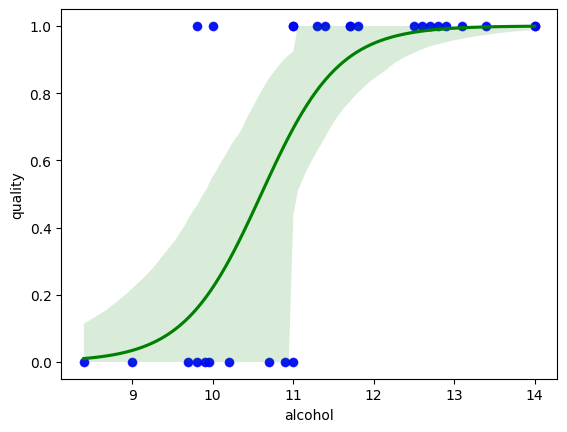

In [57]:
df_LR = dfr.loc[(dfr['quality'] == 3 ) | (dfr['quality'] == 8 ), ['alcohol','quality']]

df_LR.loc[df_LR.quality == 3, 'quality'] = 0
df_LR.loc[df_LR.quality == 8, 'quality'] = 1

df_LR.plot.scatter(x = 'alcohol', y = 'quality')

X = df_LR[['alcohol']]
y = df_LR.quality
sns.regplot(x = X, y = y, logistic = True, scatter_kws={'color': 'blue'}, line_kws={'color': 'green'})

Proper logistic regression with scikit-learn.

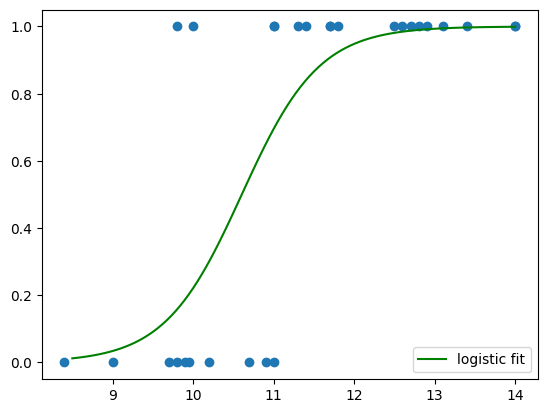

In [52]:
from sklearn.linear_model import LogisticRegression
from scipy.special import expit

X = df_LR[['alcohol']]
y = df_LR.quality
model = LogisticRegression(C = 1e9)
model.fit(X, y)

x_test = np.linspace(8.5,14.0,100)
# predict dummy y_test data based on the logistic model
y_test = x_test * model.coef_ + model.intercept_

sigmoid = expit(y_test)
plt.scatter(X,y)

# ravel to convert the 2-d array to a flat array
plt.plot(x_test,sigmoid.ravel(),c = "green", label = "logistic fit")
plt.legend(loc = "lower right")


Multiple logistic regression: for binary classification, a probability less than .5 will predict 0 while a probability greater than 0 will predict 1. We split the dataset, with 33% of the data being used for testing.

In [78]:
from sklearn.model_selection import train_test_split

X = df_wine.drop(['quality', 'hue'], axis=1)
y = df_wine['hue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)

We will standardize the training data.

In [79]:
from sklearn import preprocessing
scaler = preprocessing.StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

Train the model.

In [80]:
lr = LogisticRegression(random_state = 0)
lr.fit(X_train, y_train)

LogisticRegression(random_state=0)

Test the model.

In [81]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

y_pred = lr.predict(X_test)
print("Accuracy score: " + str(accuracy_score(y_test, y_pred)))
print("\nConfusion matrix: \n" + str(confusion_matrix(y_test, y_pred)))
print("\nClassification report: \n" + str(classification_report(y_test, y_pred)))

Accuracy score: 0.9888111888111888

Confusion matrix: 
[[ 544   13]
 [  11 1577]]

Classification report: 
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       557
           1       0.99      0.99      0.99      1588

    accuracy                           0.99      2145
   macro avg       0.99      0.98      0.99      2145
weighted avg       0.99      0.99      0.99      2145



Check accuracies.

In [82]:
train_accuracy = lr.score(X_train, y_train)
test_accuracy = lr.score(X_test, y_test)
print('One-vs-rest', '-'*35,
'Accuracy in Train Group : {:.3f}'.format(train_accuracy),
'Accuracy in Test Group : {:.3f}'.format(test_accuracy), sep='\n')

One-vs-rest
-----------------------------------
Accuracy in Train Group : 0.995
Accuracy in Test Group : 0.989


Confusion matrix plot

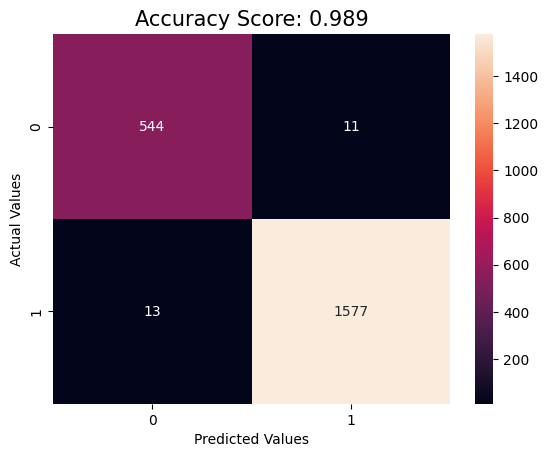

In [83]:
from sklearn.metrics import confusion_matrix as cm

predictions = lr.predict(X_test)
score = round(accuracy_score(y_test, predictions), 3)
cm1 = cm(predictions, y_test)
sns.heatmap(cm1, annot=True, fmt=".0f")
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Accuracy Score: {0}'.format(score), size = 15)
plt.show()

Check correlations of all variables with hue.

Correlation between fixed acidity and hue is -0.49
P-value of this correlation is 0.0
Correlation between volatile acidity and hue is -0.65
P-value of this correlation is 0.0
Correlation between citric acid and hue is 0.19
P-value of this correlation is 2.003735701795461e-52
Correlation between residual sugar and hue is 0.35
P-value of this correlation is 2.959354152724122e-185
Correlation between chlorides and hue is -0.51
P-value of this correlation is 0.0
Correlation between free sulfur dioxide and hue is 0.47
P-value of this correlation is 0.0
Correlation between total sulfur dioxide and hue is 0.70
P-value of this correlation is 0.0
Correlation between density and hue is -0.39
P-value of this correlation is 7.319604640413272e-236
Correlation between pH and hue is -0.33
P-value of this correlation is 5.923307967208295e-164
Correlation between sulphates and hue is -0.49
P-value of this correlation is 0.0
Correlation between alcohol and hue is 0.03
P-value of this correlation is 0.00

<Axes: >

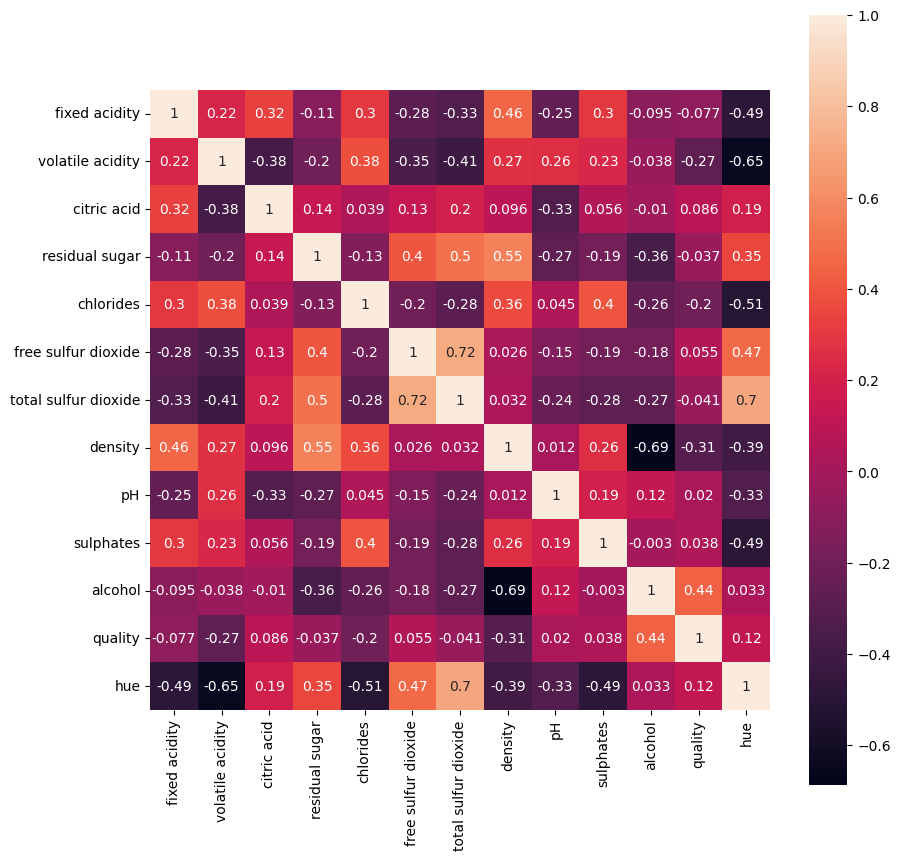

In [101]:
get_corr('fixed acidity', 'hue', df_wine)
get_corr('volatile acidity', 'hue', df_wine)
get_corr('citric acid', 'hue', df_wine)
get_corr('residual sugar', 'hue', df_wine)
get_corr('chlorides', 'hue', df_wine)
get_corr('free sulfur dioxide', 'hue', df_wine)
get_corr('total sulfur dioxide', 'hue', df_wine)
get_corr('density', 'hue', df_wine)
get_corr('pH', 'hue', df_wine)
get_corr('sulphates', 'hue', df_wine)
get_corr('alcohol', 'hue', df_wine)

correlation = df_wine.corr(method='pearson')

fig = plt.gcf()

fig.set_size_inches(10,10)

sns.heatmap(correlation, annot = True,square = True)

Clearly, the total sulfur dioxide is the parameter that is most relevant to this problem. We can implement the classification based on only this feature.

In [123]:
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

X = df_wine[['total sulfur dioxide']]
y = df_wine['hue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)

scaler = preprocessing.StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

lr = LogisticRegression(random_state = 0)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
print("Accuracy score: " + str(accuracy_score(y_test, y_pred)))
print("\nConfusion matrix: \n" + str(confusion_matrix(y_test, y_pred)))
print("\nClassification report: \n" + str(classification_report(y_test, y_pred)))

Accuracy score: 0.9184149184149184

Confusion matrix: 
[[ 439  118]
 [  57 1531]]

Classification report: 
              precision    recall  f1-score   support

           0       0.89      0.79      0.83       557
           1       0.93      0.96      0.95      1588

    accuracy                           0.92      2145
   macro avg       0.91      0.88      0.89      2145
weighted avg       0.92      0.92      0.92      2145

